In [ ]:
#creating a neural network
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms

In [ ]:
#getting dataset
from torchvision import datasets
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor()
)

In [ ]:
print(len(train_data))
print(len(test_data))

60000
10000


In [ ]:
image, label = train_data[0]
print(f"Image type: {type(image)}")
print(f"Image shape: {image.shape}")
print(f"Label type: {type(label)}")
print(f"Label: {label}")

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([1, 28, 28])
Label type: <class 'int'>
Label: 9


In [ ]:
train_data.classes
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [ ]:
image.shape
#1color channel , h , w
print(f"Label: {label}, Class name: {train_data.classes[9]}")

Label: 9, Class name: Ankle boot


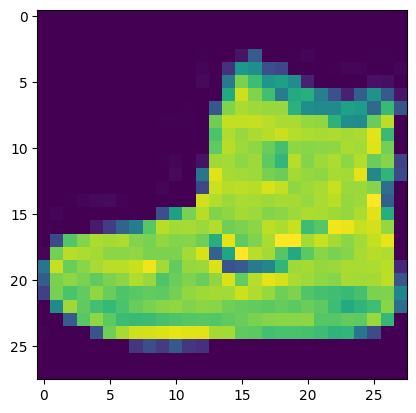

In [ ]:
#visualize the data
import matplotlib.pyplot as plt
image , label = train_data[0]
plt.imshow(image.squeeze())
# plt.figure(figsize=(10,10))



Text(0.5, 1.0, 'Ankle boot')

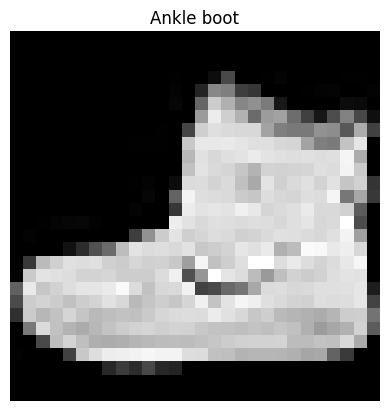

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.axis('off')
plt.title(train_data.classes[label])

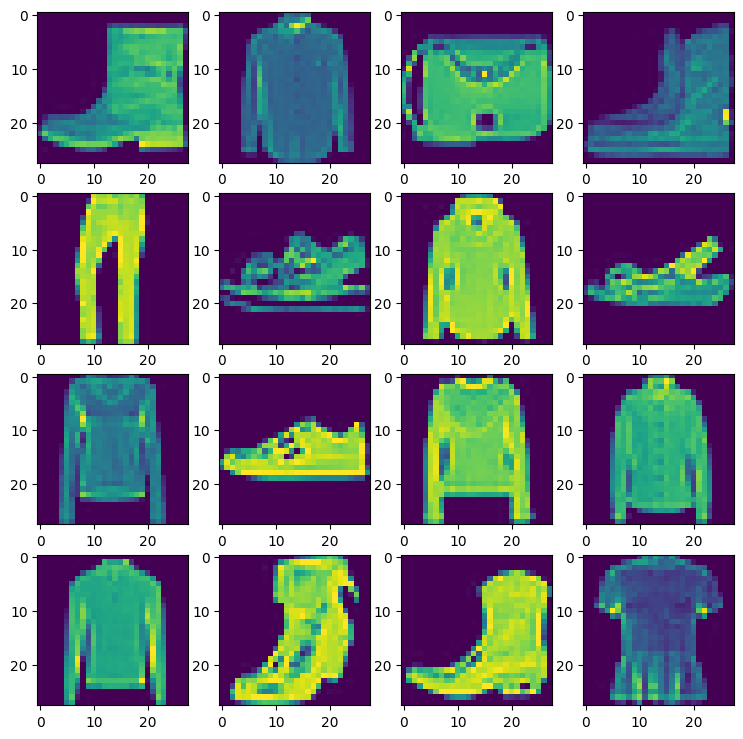

In [ ]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9 , 9))

for i in range(1 , 17):
  random_index = torch.randint(0 , len(train_data) , size = [1]).item()
  image , label  = train_data[random_index]
  fig.add_subplot(4 , 4 , i)
  plt.imshow(image.squeeze())


In [ ]:
#dviding the dataset into batchsize of 32
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader

# Redefining train_data and test_data to ensure they are in scope
# train_data = datasets.FashionMNIST(
#     root="data",
#     train=True,
#     download=True,
#     transform=torchvision.transforms.ToTensor(),
# )
# test_data = datasets.FashionMNIST(
#     root="data",
#     train=False,
#     download=True,
#     transform=torchvision.transforms.ToTensor()
# )

BATCH_SIZE=32

train_dataloader = DataLoader(dataset=train_data , batch_size =BATCH_SIZE , shuffle=True)
test_dataloader = DataLoader(dataset=test_data , batch_size=BATCH_SIZE , shuffle=False)
train_dataloader , test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x784d886f2f00>,
 <torch.utils.data.dataloader.DataLoader at 0x784d85ab6840>)

In [ ]:
print(train_dataloader , test_dataloader)
print(len(train_dataloader) , len(test_dataloader))


<torch.utils.data.dataloader.DataLoader object at 0x784d886f2f00> <torch.utils.data.dataloader.DataLoader object at 0x784d85ab6840>
1875 313


In [ ]:
train_features_batch , train_labels_batch = next(iter(train_dataloader))


6


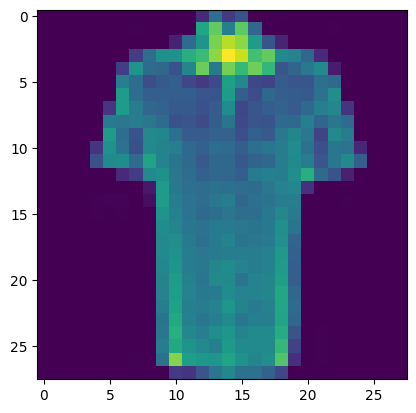

In [ ]:

torch.manual_seed(42)
# for i in range(0 , 32):
random_index = torch.randint(0 , len(train_features_batch) , size=[1]).item()
img , label = train_features_batch[random_index] , train_labels_batch[random_index]
plt.imshow(img.squeeze())
print(random_index)

In [ ]:
#building a model starting with the basline model

#create a flatten layer

flatten_model = nn.Flatten()

x = train_features_batch[0]
output = flatten_model(x)
#perform forward pass

x.shape , output.shape

(torch.Size([1, 28, 28]), torch.Size([1, 784]))

In [ ]:
from torch import  nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self , input_shape , output_shape , hidden_units):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten() ,
        nn.Linear(in_features=input_shape , out_features=hidden_units) ,
        nn.Linear(in_features=hidden_units , out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model0= FashionMNISTModelV0(input_shape=28*28 , output_shape=len(train_data.classes) , hidden_units=10)
model0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

In [ ]:
dumm_x = torch.rand([1 , 1 , 28 , 28])
model0(dumm_x  )

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model0.parameters() , lr=0.1)


In [ ]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import time

start_time = time.time()
print(f"Start time: {start_time}")

# Simulate some work (replace with your actual code)
for _ in range(1000000):
    pass

end_time = time.time()
print(f"End time: {end_time}")

elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

Start time: 1774862501.3475282
End time: 1774862501.3953104
Elapsed time: 0.0478 seconds


In [ ]:
import time

#traing test  , using tqdm

from tqdm.auto import tqdm
from helper_functions import accuracy_fn

torch.manual_seed(42)
# train_time_start_on_cpu = timer()
epochs = 3

for epoch in range(epochs):
  train_loss = 0
  train_acc = 0
  print(f"Epoch: {epoch+1}\n------")
  #training
  model0.train()
  for batch , (X , y) in enumerate(tqdm(train_dataloader)):
    y_pred = model0(X)
    loss = loss_fn(y_pred , y)
    train_loss += loss.item()
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  #testing
  test_loss = 0
  test_acc = 0
  model0.eval()
  with torch.inference_mode():
    for X_test , y_test in test_dataloader:
      test_pred = model0(X_test)
      test_loss += loss_fn(test_pred , y_test).item()
      test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  print(f"Train loss: {train_loss:.4f} | Train accuracy: {train_acc:.2f}% | Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.2f}%")

Epoch: 1
------


  0%|          | 0/1875 [00:00<?, ?it/s]

Train loss: 0.5893 | Train accuracy: 79.26% | Test loss: 0.5468 | Test accuracy: 80.61%
Epoch: 2
------


  0%|          | 0/1875 [00:00<?, ?it/s]

Train loss: 0.4765 | Train accuracy: 83.16% | Test loss: 0.4886 | Test accuracy: 82.70%
Epoch: 3
------


  0%|          | 0/1875 [00:00<?, ?it/s]

Train loss: 0.4541 | Train accuracy: 84.06% | Test loss: 0.4674 | Test accuracy: 83.64%


In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  loss , acc = 0 , 0
  model.eval()
  with torch.inference_mode():
    for X , y in dataloader:
      # Make predictions
      y_pred = model(X)

      # Accumulate loss and accuracy
      loss += loss_fn(y_pred , y).item()
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    # Scale loss and acc
    loss /= len(dataloader)
    acc /= len(dataloader)
  return loss , acc

model0_result = eval_model(model=model0 ,
                           dataloader=test_dataloader ,
                           loss_fn=loss_fn,
                           accuracy_fn=accuracy_fn)

print(model0_result)

(0.4673857182359543, 83.6361821086262)


Creating a new model with non linearity


In [ ]:
from torch.nn.parallel.data_parallel import T
#----------------

class FashionMNISTModelV1(nn.Module):
  def __init__(self , input_shape , output_shape , hidden_units):
    super().__init__()
    self.layer_stack = nn.Sequential(
                                    nn.Flatten() ,
                                    nn.Linear(in_features=input_shape , out_features=hidden_units) ,
                                    nn.ReLU(),
                                    nn.Linear(in_features=hidden_units , out_features=output_shape),
                                    nn.ReLU()
    )

  def forward(self  , x:torch.Tensor):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model1 = FashionMNISTModelV1(input_shape=28*28 , output_shape=len(train_data.classes) , hidden_units=10)
next(model1.parameters())

Parameter containing:
tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
        [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
        [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
        ...,
        [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
        [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
        [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]],
       requires_grad=True)

In [ ]:
#setup loss
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model1.parameters() , lr=0.1)


In [ ]:
import tqdm

def train_step(model : torch.nn.Module ,
               data_loader : torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn):
  model.train()
  train_loss , train_acc = 0 , 0
  for batch , (X , y) in enumerate(tqdm.tqdm(data_loader)):
    # Move data to target device
    X, y = X.to(device), y.to(device)

    y_pred = model(X)
    loss = loss_fn(y_pred , y)
    train_loss += loss.item()
    train_acc += accuracy_fn(y_true=y , y_pred=y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch % 400 == 0:
      print(f"{batch*len(X)}/{len(train_dataloader.dataset)}")

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  return train_loss , train_acc

In [ ]:
def test_step(model : torch.nn.Module,
              data_loader : torch.utils.data.DataLoader,
              loss_fn : torch.nn.Module,
              accuracy_fn = accuracy_fn):

  test_loss , test_acc = 0 , 0 # Initialize test_acc
  model.eval()
  with torch.inference_mode():
    for X , Y in data_loader:
      x , y = X.to(device) , Y.to(device) # Move data to target device
      test_pred = model(x)
      test_loss += loss_fn(test_pred , y).item()
      test_acc += accuracy_fn(y_true=y , y_pred=test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
  return test_loss, test_acc # Return test_loss and test_acc

In [ ]:
torch.manual_seed(42)
epochs = 3
# BATCH_SIZE
for epoch in range(epochs):
  train_step(model=model1.to(device), data_loader=train_dataloader , loss_fn=loss_fn , optimizer=optimizer  ,
            accuracy_fn=accuracy_fn
             )
  test_loss, test_acc = test_step(model=model1.to(device) , data_loader = test_dataloader , loss_fn = loss_fn , accuracy_fn=accuracy_fn )
  print(f"Epoch {epoch+1} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

  1%|          | 23/1875 [00:00<00:31, 58.26it/s]

0/60000


 24%|██▎       | 443/1875 [00:02<00:07, 193.08it/s]

12800/60000


 45%|████▍     | 840/1875 [00:04<00:04, 231.80it/s]

...

38400/60000


 87%|████████▋ | 1632/1875 [00:07<00:01, 224.64it/s]

51200/60000


100%|██████████| 1875/1875 [00:08<00:00, 209.81it/s]


Epoch 3 | Test Loss: 0.6691 | Test Accuracy: 75.87%


In [ ]:
# reult  non linearity didnt pass the linear model
